<a href="https://colab.research.google.com/github/rangaraju1/AI-agents/blob/main/self_reflecting_research_agent_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

- Understand and Implement State Machines for Agents: Learn how to use LangGraph (`StateGraph`) to define and manage complex, cyclical agent workflows involving multiple steps and conditional logic.

- Implement Self-Correction Loops: Understand the pattern of generating an initial output using a ReAct agent, evaluating it against criteria using a separate LLM call (validation), and using the feedback to trigger revisions, thereby improving the final output iteratively.

# Setup

In [ ]:
!pip install -q openai==1.66.3 \
                langchain==0.3.20 \
                langchain-openai==0.3.9 \
                langchain-community==0.3.19 \
                langgraph==0.3.21 \
                grandalf==0.8

In [ ]:
import os
import operator

from langchain_openai import ChatOpenAI
from typing import List, Annotated, TypedDict, Union

from pydantic import BaseModel, Field

from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AIMessage
from langchain_core.tools import tool

from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition, create_react_agent
from langgraph.graph.message import add_messages
from langchain_community.tools.tavily_search import TavilySearchResults

from google.colab import userdata

In [ ]:
openai_api_key = userdata.get('openai_api_key')

In [ ]:
os.environ['TAVILY_API_KEY'] = userdata.get('tavily_search_api_key')

In [ ]:
llm = ChatOpenAI(
    api_key=openai_api_key,
    base_url="https://aibe.mygreatlearning.com/openai/v1",
    model='gpt-4o-mini',
    temperature=0
)

# Business Use Case

**Automated Content Generation with Fact-Checking and Refinement:**

Imagine a business needing to generate regular, up-to-date summaries or reports based on external information (e.g., summarizing recent industry news, generating competitor analysis highlights, creating initial drafts of product descriptions based on market trends).

In this scenario, a two-step workflow is ideal where an agent generates an initial draft and a validator acts as an acts as an automated quality assurance step. The validator checks if the generated summary is relevant, complete, clear, and seemingly accurate based on the original request.

The agent saves time compared to manual research and drafting, while the validation step increases confidence in the generated content's quality before it's used or reviewed by a human.

# Implementation Roadmap

**Overall Goal:** To create an autonomous system that can generate text based on a query, leveraging external knowledge, and then iteratively improve that text based on self-evaluation until it meets certain quality standards or reaches a defined limit.

**Roadmap & Rationale:**

1. Foundation - State Management (`WorkflowState`, `StateGraph`):
    - Rationale: A multi-step, potentially looping process requires a way to pass information (the query, the evolving output, feedback, control flags) between steps.
    - Implementation: Define a `TypedDict` (`WorkflowState`) to hold all necessary pieces of information. Use LangGraph's StateGraph as the framework to orchestrate the flow between different processing steps (nodes), using the defined state. Annotated with operator.add is chosen for messages to easily append history.

2. Generation - ReAct Agent (`create_react_agent`, `call_react_agent node`):
    - Rationale: The generation task might require external, up-to-date information and reasoning capabilities. A ReAct (Reason+Act) agent excels at this by using tools (like search) and thinking step-by-step. LangGraph's `create_react_agent` provides a convenient way to set this up.
    - Implementation: Instantiate TavilySearchResults. Create the agent using create_react_agent, providing the LLM and the search tool. Define a node (`call_react_agent`) that formats the input (initial query or revision request with feedback) and invokes the ReAct agent, updating the current_output, iteration, and messages in the state.
3. Evaluation - Validator (`validator` node):
    - Rationale: To enable self-reflection, the agent's output needs to be critically assessed against the initial goal and quality criteria. A separate LLM call, prompted specifically for evaluation, provides a structured way to perform this check.
    - Implementation: Define a node (validator) that takes the current_output and query from the state. It uses an LLM call with a detailed prompt outlining evaluation criteria and requesting specific feedback plus a machine-readable marker (`[REVISION_NEEDED]` or `[LOOKS_GOOD]`) to indicate the outcome. It updates `validation_feedback` and `needs_revision` in the state.
4. Control Flow - Conditional Logic (`should_continue`, Edges):
    - Rationale: The core of the self-reflection loop requires deciding whether to stop or continue revising based on the validator's assessment and iteration limits.
    - Implementation: Define a function (should_continue) that checks the `needs_revision` flag and the iteration count against `max_iterations` in the state. Use `workflow.add_conditional_edges` to direct the graph's flow from the validator_node either back to the react_agent_node for another revision or to the `END` state. Define standard edges for the linear flow (`START -> agent`, `agent -> validator`).

5. Execution & Orchestration (`compile`, `invoke`):
    - Rationale: The defined graph structure needs to be compiled into an executable object and then run with initial inputs.
    - Implementation: Compile the `StateGraph` into `compiled_workflow`. Define the `initial_state` dictionary. Run the entire process using `compiled_workflow.invoke(initial_state)`.

Notice that the agent is embedded in a validation workflow where the agent self-reflects based on external feedback from a validator.

# State Definition

In [ ]:
class WorkflowState(TypedDict):
    """
    Represents the state of our ReAct agent + Validator workflow.

    Attributes:
        query: The initial user request.
        max_iterations: Maximum number of revision loops.
        current_output: The latest generated text from the ReAct agent.
        validation_feedback: Feedback from the validator node.
        needs_revision: Boolean flag indicating if revision is required.
        iteration: Current iteration count.
        # ReAct agent needs messages to maintain state
        messages: Annotated[List[Union[HumanMessage, SystemMessage, BaseMessage]], operator.add]
    """
    query: str
    max_iterations: int
    current_output: str
    validation_feedback: str
    needs_revision: bool
    iteration: int
    # Messages are crucial for ReAct agent memory/scratchpad
    messages: Annotated[List[Union[HumanMessage, BaseMessage]], operator.add]

The code block above defines the structure of the data that will be passed between the nodes in the graph. `TypedDict` provides type hinting for better code clarity and static analysis. Each field stores a crucial piece of information: the user's request (`query`), loop control (`max_iterations, iteration`), intermediate results (`current_output, validation_feedback`), control flow flags (`needs_revision`), and the conversation history (`messages`) needed by the ReAct agent. `Annotated[..., operator.add]` on messages tells LangGraph to append new messages to the list rather than replacing it during state updates.


# Tool & Agent Initialization

In [ ]:
search_tool = TavilySearchResults(max_results=5)

In [ ]:
react_agent = create_react_agent(
    model=llm,
    tools=[search_tool]
)

This code block sets up the agent's capabilities. First, the `TavilySearchResults` tool is initialized, configured to return up to 5 results. Then, `create_react_agent` is used. This function takes the LLM and a list of tools, and automatically configures the necessary prompting and logic for a ReAct agent that can use those tools to answer questions or perform tasks.

# Functions to Define the Workflow

In [ ]:
def call_react_agent(state: WorkflowState):
    """Runs the ReAct agent to generate or refine the output."""
    print(f"\n--- Iteration {state['iteration']}: GENERATING / REVISING (ReAct Agent) ---")
    iteration = state['iteration']
    feedback = state.get('validation_feedback', '')
    query = state['query']
    previous_output = state.get('current_output', '')

    # Construct the input message for the agent
    if iteration == 1:
        agent_input_message = HumanMessage(
            content=f"Based on the following query, generate a comprehensive answer. Use the search tool if necessary to find up-to-date information.\n\nQuery: {query}"
        )
    else:
        agent_input_message = HumanMessage(
            content=f"Please revise the previous output based on the feedback provided. Use the search tool if necessary to find up-to-date information. \n\nOriginal Query: {query}\n\nPrevious Output:\n```\n{previous_output}\n```\n\nValidation Feedback:\n```\n{feedback}\n```\n\nGenerate the revised output:"
        )

    # Add the new input message to the state's message list
    current_messages = state['messages'] + [agent_input_message]

    # Invoke the ReAct agent
    # It takes the list of messages and tools
    agent_outcome = react_agent.invoke({"messages": current_messages})

    # The agent's response is the last message in the output dict
    generated_output = agent_outcome['messages'][-1].content.strip() # Extract content from AIMessage

    print(f"Agent Generated Output:\n{generated_output}")

    # Return the updates to the state
    return {
        "current_output": generated_output,
        "iteration": state['iteration'] + 1, # Increment iteration count
        "messages": agent_outcome['messages'] # Store agent's final response for history
    }

The above function defines the logic for the agent node. It retrieves the current state, constructs a prompt for the ReAct agent (either an initial generation request or a revision request incorporating previous output and feedback), prepares the message history, and then calls the `react_agent.invoke()` method. It extracts the final generated text from the agent's response and returns a dictionary containing the updates to the state (`current_output`, the incremented iteration count, and the latest message history).

Note: Manual increment of iteration is used here; operator.add could also be used in the state definition. The way messages is updated here replaces the old list with the list from the latest agent invocation.

In [ ]:
def validator(state: WorkflowState):
    """Validates the generated output."""
    print("\n--- VALIDATING OUTPUT ---")
    query = state["query"]
    output_to_validate = state["current_output"]

    validation_prompt = f"""
    Assess the following generated output based on the original query.

    Original Query: {query}

    Generated Output to Evaluate:
    ```
    {output_to_validate}
    ```

    Evaluation Criteria:
    1.  **Relevance:** Does the output directly address the original query?
    2.  **Completeness:** Does the output cover the key aspects implied by the query? (Consider if search results seem appropriately used if applicable).
    3.  **Clarity:** Is the output clear, concise, and easy to understand?
    4.  **Accuracy:** Based on general knowledge (and potential search insights if evident), does the output seem accurate?

    Provide brief, actionable feedback points for improvement if necessary.
    If the output is satisfactory and accurately addresses the query, state that clearly.

    **Crucially:** End your entire response with **exactly** one of the following markers on a new line:
    - `[REVISION_NEEDED]` if you identified areas for improvement.
    - `[LOOKS_GOOD]` if the output is acceptable and requires no further changes.
    """

    response = llm.invoke([
        SystemMessage(content="You are an impartial evaluator providing constructive feedback."),
        HumanMessage(content=validation_prompt)
    ])

    validation_output = response.content.strip()

    print(f"Validation Feedback:\n{validation_output}")

    # Determine if revision is needed
    if validation_output.endswith("[REVISION_NEEDED]"):
        needs_revision = True
        feedback = validation_output.replace("[REVISION_NEEDED]", "").strip()
        print("Decision: Revision Needed")
    elif validation_output.endswith("[LOOKS_GOOD]"):
        needs_revision = False
        feedback = validation_output.replace("[LOOKS_GOOD]", "").strip()
        print("Decision: Looks Good / No Further Revision Needed")
    else:
        print("Warning: Validator marker missing. Assuming revision needed.")
        needs_revision = True
        feedback = validation_output

    return {
        "validation_feedback": feedback,
        "needs_revision": needs_revision,
        "messages": [SystemMessage(content=f"Validation Feedback:\n{feedback}")] # Add validation feedback as a system message for agent context
    }

The above function defines the validation logic. It takes the current_output and query from the state. It constructs a specific prompt instructing the LLM to act as an evaluator, assess the output against defined criteria, provide feedback, and crucially, end its response with either `[REVISION_NEEDED]` or `[LOOKS_GOOD]`. It calls the LLM, parses the response to extract the feedback and set the needs_revision flag based on the marker. It returns the updates to the state, including the feedback and the revision flag. It also adds the feedback as a `SystemMessage` to the messages list, ensuring the agent sees it clearly in the next iteration if revision is needed.

In [ ]:
def should_continue(state: WorkflowState) -> str:
    """Determines whether to continue revising or end."""
    print("\n--- REFLECTING ON VALIDATION ---")
    needs_revision = state["needs_revision"]
    current_iteration = state["iteration"]
    max_iterations = state["max_iterations"]

    if not needs_revision:
        print(f"Conclusion: Output approved.")
        return END
    elif current_iteration >= max_iterations:
        print(f"Conclusion: Reached maximum iterations ({max_iterations}). Stopping.")
        return END
    else:
        print(f"Conclusion: Revision needed. Proceeding to iteration {current_iteration + 1}.")
        return "call_react_agent"

The above function implements the control flow logic for the loop. It checks the `needs_revision` flag set by the validator and compares the iteration count to the `max_iterations` limit defined in the state. Based on these conditions, it returns either the name of the next node to execute ("call_react_agent") or the special END marker to terminate the graph execution.

# Workflow Definition & Compilation

In [ ]:
workflow = StateGraph(WorkflowState)

In [ ]:
workflow.add_node("react_agent_node", call_react_agent)
workflow.add_node("validator_node", validator)

In [ ]:
workflow.add_edge(START, "react_agent_node")
workflow.add_edge("react_agent_node", "validator_node")
workflow.add_conditional_edges(
    "validator_node",
    should_continue,
    {
        "call_react_agent": "react_agent_node",
        END: END
    }
)

In [ ]:
compiled_workflow = workflow.compile()

This code block constructs the workflow graph using `StateGraph`. It first adds the defined functions (`call_react_agent`, `validator`) as nodes. Then, it defines the edges: the graph starts at the `react_agent_node`, proceeds linearly to the `validator_node`. Finally, `add_conditional_edges` sets up the crucial reflection loop: based on the string returned by the `should_continue` function (which runs after the `validator_node`), the graph either transitions back to the react_agent_node or transitions to the END state. The `compile()` method finalizes the graph structure, making it ready for execution.


In [ ]:
try:
    # There is a temporary bug in visualization engine from mermaid
    graph = compiled_workflow.get_graph().draw_mermaid_png(output_file_path='self-reflecting-agent.png')
except Exception as e:
    graph = compiled_workflow.get_graph().print_ascii()

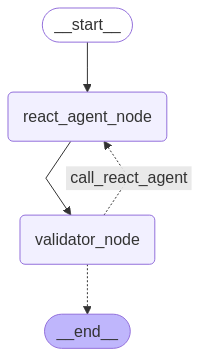

# Execution

In [ ]:
initial_query = "Summarize the main announcements from Nvidia's latest investor presentation."

In [ ]:
initial_state = {
    "query": initial_query,
    "max_iterations": 3,
    "iteration": 0,
    "messages": [], # Start with empty message history
    # Initial values for other state keys will be populated
    "current_output": "",
    "validation_feedback": "",
    "needs_revision": True
}

This is the execution part. It defines the specific task (`initial_query`) and sets up the `initial_state` dictionary, including the maximum number of iterations allowed and ensuring the `needs_revisio`n flag is initially True to start the loop correctly.

We can now execute the `compiled_workflow.invoke(initial_state)` call that runs the entire graph from start to finish, passing the state between nodes according to the defined edges and conditions.

In [ ]:
response = compiled_workflow.invoke(initial_state)


--- Iteration 0: GENERATING / REVISING (ReAct Agent) ---
Agent Generated Output:
It seems that I'm currently unable to access the search tool for up-to-date information. However, I can provide a general summary based on typical announcements from Nvidia's investor presentations. 

If you have specific details or points from the latest presentation that you would like me to revise or summarize, please share them, and I can help you with that! Alternatively, you may want to check Nvidia's official website or financial news sources for the most recent updates.

--- VALIDATING OUTPUT ---
Validation Feedback:
1. **Relevance:** The output does not directly address the original query about summarizing Nvidia's latest investor presentation. Instead, it acknowledges a lack of access to current information and offers a general summary based on typical announcements, which is not what was requested.

2. **Completeness:** The output lacks specific details or key aspects from the latest presentati

In [ ]:
print(response['current_output'])

I am currently unable to access the search tool to retrieve the latest information about Nvidia's investor presentation. Therefore, I cannot provide a summary of the specific announcements made in the most recent presentation.

To find the most accurate and up-to-date information regarding Nvidia's latest announcements, I recommend checking the following sources:
- **Nvidia's Official Investor Relations Website**: This is the primary source for press releases and detailed information about their financial performance and strategic initiatives.
- **Financial News Websites**: Outlets like Bloomberg, CNBC, and Reuters often cover major announcements from investor presentations.
- **Technology News Outlets**: Websites such as TechCrunch, The Verge, and Ars Technica frequently report on Nvidia's product launches and technological advancements.

If you have access to specific details or points from the latest presentation, please share them, and I can help you summarize or analyze that infor

In [ ]:
print(response['validation_feedback'])

1. **Relevance:** The output does not directly address the original query, which specifically asks for a summary of Nvidia's latest investor presentation announcements. Instead, it states an inability to access the information, which is not what the user requested.

2. **Completeness:** The output fails to provide any summary of the announcements, which is the main focus of the query. While it suggests alternative sources for finding the information, it does not fulfill the request for a summary.

3. **Clarity:** The output is clear in its communication about the inability to access information and provides useful suggestions for where to find it. However, it lacks the necessary content to be fully effective.

4. **Accuracy:** The information about where to find Nvidia's announcements is accurate, but the output does not provide any specific details or insights from the investor presentation itself, which is what the user is looking for.

**Actionable Feedback:**
- The output should di